In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

from astropy.nddata import CCDData
from astropy import units as u
from astropy.table import QTable, vstack
from astropy.wcs.utils import proj_plane_pixel_scales
from astroquery.xmatch import XMatch
from astropy.table import Table

from astroquery.astrometry_net import AstrometryNet

import ccdproc as ccdp

import sep

# zscale stretch factor
stretch = 4
phot_circ_radius = 21

matplotlib.rcParams.update({'font.size': 12})

%matplotlib inline

### Locate all images

In [2]:
read_path = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/solve/'
img_table_solved = QTable.read(read_path + 'tabulated_solved.fits')

Perform photometry on the best images: daytime, 0.1 s exposure, base gain, solved

In [ ]:
default_gain = abs(img_table_solved['GAINFACT'] - 4.0) < 1e-3
default_exp = abs(img_table_solved['EXPTIME'] - 0.2 * u.s) < 1e-3 * u.s
solved = img_table_solved['SOLVED'] > 0
daytime_float = []
for fname in img_table_solved['FILES']:
    if (
        (('10-01_18' in fname)
        or ('10-01_19' in fname)
        or ('10-01_20' in fname)
        or ('10-01_21' in fname)
        or ('10-01_22' in fname)
        or ('10-01_23' in fname)
        or ('10-02_00' in fname))
        # and ('01_20-47' in fname) # kap Lyr
    ):
        daytime_float.append(1)
        # print(fname)
    else:
        daytime_float.append(0)
daytime_float = np.array(daytime_float)
candidates = (default_gain & default_exp & daytime_float & solved)

In [4]:
# reduced data path
direc = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/'
calibrated_data = Path(direc)
calibrated_data.mkdir(exist_ok=True)

After an autofocus, one frame is captured with AF settings, and should not be considered. Exclude them on grounds of difference in file size (noise level).

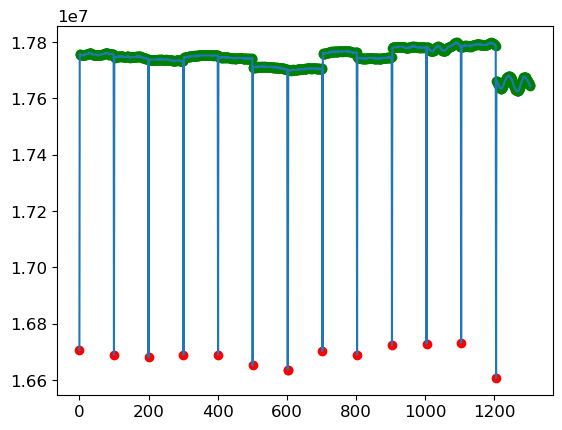

In [6]:
bkg_mean = img_table_solved[candidates]['FILESIZE']
mu, sig = np.mean(bkg_mean), np.std(bkg_mean)
condition = np.abs(bkg_mean - mu) > 3*sig
outliers = np.where(condition)[0]
inliers = np.where(~condition)[0]
plt.figure()
plt.plot(img_table_solved[candidates]['FILESIZE'])
plt.scatter(np.arange(len(img_table_solved[candidates]))[outliers], img_table_solved[candidates][outliers]['FILESIZE'], color='r')
plt.scatter(np.arange(len(img_table_solved[candidates]))[inliers], img_table_solved[candidates][inliers]['FILESIZE'], color='g')
plt.show()

In [49]:
img_table_solved[candidates][inliers]
fig, ax  = plt.subplots()
ax.scatter(img_table_solved[img_table_solved['SOLVED'] > 0]['TIMESTAMP'], img_table_solved[img_table_solved['SOLVED'] > 0]['GAINFACT'])

In [ ]:
good_files = img_table_solved[candidates][inliers]['FILES']
good_basenames = [os.path.basename(f) for f in good_files]

In [8]:
sci_cal = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/sci/', glob_include=f'*.fits.fz')

### Science: aperture photometry

In [9]:
def get_photometry(in_table, match_radius=20*u.arcsec, RPmag_max=1, RPmag_limit=9):
    # query_cat = 'vizier:I/355/gaiadr3'
    query_cat = 'vizier:I/259/tyc2'
    # query_cat = 'vizier:II/237/colors' # johnson
    results = XMatch.query(
        cat1=in_table,
        colRA1='ra',
        colDec1='dec',
        cat2=query_cat,
        # colRA2='RAJ2000',
        # colDec2='DEJ2000',
        colRA2='RA_ICRS',
        colDec2='DE_ICRS',
        # colRA2='_RA.icrs', # vizier-computed, more accurate would be J1950->J2000 precessed
        # colDec2='_DE.icrs', # vizier-computed, more accurate would be J1950->J2000 precessed
        max_distance=match_radius
    )
    # bluer and redder passbands
    # B = results['BPmag']
    # R = results['RPmag']
    B = results['BTmag']
    R = results['VTmag']
    # R = results['Vmag']
    # B = results['B-V'] + results['Vmag']
    valid = (R < RPmag_limit) & (R > RPmag_max)
    return results[valid], B[valid], R[valid]


def sep_flatfield(img):
    z = img.astype(np.float64)
    opts = dict(
        # bw=78,
        # bh=78,
        # fw=16,
        # fh=16
    )
    flat_data = sep.Background(z, **opts)
    return flat_data

In [10]:
%matplotlib qt
plt.ion()
fig, ax = plt.subplots()
ax.axhline(3, linestyle='--', color='k')

all_results = []
for j, sci in enumerate(sci_cal.files):
    # print(sci)
    if os.path.basename(sci) not in good_basenames:
        # print('skipping', sci)
        continue
    ccdobj = CCDData.read(calibrated_data / 'sci' / sci)
    img = ccdobj.data
    # img is in e-/s after cal

    border = 100
    mask = np.ones_like(img)
    mask[border:-border, border:-border] = 0 # 1-masked elements are ignored
    mask = mask.astype(bool)

    bkg = sep_flatfield(img)

    data_sub = img - bkg.back()

    objects = sep.extract(data_sub, 1.5, err=bkg.globalrms, mask=mask)

    if len(objects) < 1:
        continue

    # do photometry
    flux, fluxerr, flag = sep.sum_circle(
        data_sub, objects['x'], objects['y'], phot_circ_radius,
        bkgann=(phot_circ_radius,phot_circ_radius+10),
        err=bkg.rms(),
        # gain=1.0
    )

    # m, s = np.mean(data_sub), np.std(data_sub)
    # figtmp, axtmp = plt.subplots(figsize=(12,6))
    # axtmp.imshow(data_sub, vmin=m-s, vmax=m+5*s, origin='lower')
    # for obj in objects:
    #     circ = matplotlib.patches.Circle(
    #         (obj['x'], obj['y']),
    #         radius=phot_circ_radius, facecolor='none', edgecolor='w')
    #     axtmp.add_artist(circ)
    #     circ = matplotlib.patches.Circle(
    #         (obj['x'], obj['y']),
    #         radius=phot_circ_radius+10, facecolor='none', edgecolor='w', linestyle='--')
    #     axtmp.add_artist(circ)
    # figtmp.show()

    idx_sort = np.argsort(flux)[::-1]
    flux = flux[idx_sort]
    objects = objects[idx_sort]

    instrumental_mags = -2.5 * np.log10(flux)
    # for i in range(len(flux)):
    #     print("object {:d}: flux = {:f} +/- {:f}, SNR {:f}, mag {:f}".format(i, flux[i], fluxerr[i], flux[i] / fluxerr[i], -2.5 * np.log10(flux[i])))

    # observed coordinates
    wcs = ccdobj.wcs
    radec = wcs.pixel_to_world(objects['x'], objects['y'])
    radec_j2000 = radec.transform_to('fk5')
    tab = Table(
        [radec_j2000.ra, radec_j2000.dec, instrumental_mags, flux, fluxerr, objects['flux']],
        names=['ra', 'dec', 'inst_mag', 'flux', 'fluxerr', 'flux_obj'])
    results, B, R = get_photometry(tab, match_radius=6*u.arcsec)
    # print(results)
    all_results.append(results)

    if j < np.inf:
        # print(results)
        ax.scatter(R[results['flux'] > 0], results['flux'][results['flux'] > 0] / results['fluxerr'][results['flux'] > 0], alpha=0.05)
        plt.draw()
        plt.pause(0.025)

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""
/tmp/ipykernel_1749435/468048259.py:56: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_1749435/468048259.py:56: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_1749435/468048259.py:56: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_1749435/468048259.py:56: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_1749435/468048259.py:56: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_1749435/468048259.py:56: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * np.log10(flux)
/tmp/ipykernel_1749435/468048259.py:56: RuntimeWarning: invalid value encountered in log10
  instrumental_mags = -2.5 * n

In [11]:
ax.grid(True)
# ax.set_xlabel('Gaia Rpmag')
ax.set_xlabel('Tycho Vmag')
# ax.set_xlabel('Johnson Vmag')
ax.set_ylabel('TIMcam SNR')
ax.set_title('0.2 s, Gain 2x Base')
ax.set_xlim(3,9)
ax.set_ylim(0,50)
plt.show()

In [12]:
combined_results = vstack(all_results)

In [13]:
combined_results.write('combined_200ms_gain4.fits', overwrite=True)

In [14]:
combined_results = Table.read('combined_200ms_gain4.fits')

Check source matching

In [15]:
# %matplotlib qt

m, s = data_sub.mean(), data_sub.std()

fig, ax = plt.subplots(subplot_kw=dict(projection=wcs))
ax.imshow(data_sub, interpolation='nearest', cmap='bone',
                vmin=m-2*s, vmax=m+2*s, origin='lower')
overlay = ax.get_coords_overlay('fk5')
overlay.grid(color='white', ls='dotted')
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
ax.scatter(radec_j2000.ra, radec_j2000.dec, s=100, c=flux, transform=ax.get_transform('world'))

ax.scatter(results['ra'], results['dec'], color='k', transform=ax.get_transform('world'))
# ax.scatter(results['RAmdeg'], results['DEmdeg'], color='k', transform=ax.get_transform('world'))
plt.show()

In [16]:
len(radec), len(results)

(84, 30)

In [17]:
# from io import StringIO
# # circular annulus r + 3
# # r, snr, flux
# s = '''
# 2 39 40594
# 3 37 57903
# 4 35 77488
# 5 35 101747
# 6 33 121378
# 7 31 138431
# 8 28 149506
# 9 27 165275
# 10 25 176591
# 15 17 209904
# 20 13 233666
# 21 12 234790
# 22 11 222036
# 25 8 212941
# '''
# r, snr, f = np.genfromtxt(StringIO(s), delimiter=' ', names=['r', 'snr', 'f'], unpack=True)

# fig, ax = plt.subplots()
# ax2 = ax.twinx()
# ax.plot(r, snr, label='snr')
# ax.set_ylabel('SNR')
# ax2.plot(r, f, color='r', label='flux')
# ax2.set_ylabel('Flux (e-/s in aperture)')
# ax.set_xlabel('circular radius (px)')
# fig.tight_layout()
# plt.show()

In [18]:
combined_results['snr'] = combined_results['flux'] / combined_results['fluxerr']
# combined_results['angDist', 'ra', 'dec', 'snr', 'flux', 'inst_mag', 'DR3Name', 'BPmag', 'RPmag'].pprint_all()
combined_results['angDist', 'ra', 'dec', 'snr', 'flux', 'inst_mag', 'BTmag', 'VTmag', 'HIP'].pprint_all()
# combined_results['angDist', 'ra', 'dec', 'snr', 'flux', 'inst_mag', 'Vmag', 'B-V'].pprint_all()

angDist          ra                dec                  snr                   flux              inst_mag      BTmag  VTmag  HIP  
 arcsec                                                                                                        mag    mag        
-------- ------------------ ------------------ ---------------------- ------------------- ------------------- ------ ----- ------
3.345958  240.6619200049105 47.240644668441256     15.998211399660114   418961.6804764526  -14.05543575718504  7.969 6.624  78574
1.283733 244.93560856579526  46.31319767442965     11.722741576680589   303543.1674940012 -13.705551154272227  3.701 3.854  79992
3.191095 242.19257683222446  44.93579522436584      9.500413470422368   235435.2790705901 -13.429678851851508  4.155 4.216  79101
1.645088 240.70020415496606 46.036816721273134      8.533513712315752   209328.5536025899  -13.30207118152808  4.596 4.694  78592
3.439834  242.9477076196136  42.37540817330239      7.774415071073144   193335.0502482405 

In [19]:
# fig, ax = plt.subplots()
# ax.hist(combined_results['flux'], bins=10)

In [20]:
# 1/0

Quick check of linearity and color

In [21]:
# non_nans = np.where((~np.isnan(combined_results['BPmag'])) & (~np.isnan(combined_results['RPmag'])) & (~np.isnan(combined_results['inst_mag'])))
non_nans = np.where((~np.isnan(combined_results['BTmag'])) & (~np.isnan(combined_results['VTmag'])) & (~np.isnan(combined_results['inst_mag'])))
# non_nans = np.where((~np.isnan(combined_results['Vmag'])) & (~np.isnan(combined_results['RPmag'])) & (~np.isnan(combined_results['inst_mag'])))

In [22]:
fig, ax = plt.subplots()
# ax.scatter(combined_results['inst_mag'][non_nans], combined_results['BPmag'][non_nans])
# ax.scatter(combined_results['inst_mag'][non_nans], combined_results['RPmag'][non_nans])
ax.scatter(combined_results['inst_mag'], combined_results['BTmag'])
ax.scatter(combined_results['inst_mag'], combined_results['VTmag'])
# ax.scatter(combined_results['inst_mag'][non_nans], combined_results['BPmag'][non_nans])
# ax.scatter(combined_results['inst_mag'][non_nans], combined_results['RPmag'][non_nans])
# ax.scatter(results['inst_mag'], results['BPmag'] - results['RPmag'])
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_aspect('equal')
plt.show()

Fit for our red filter zero-point, referred to the Gaia red filter system with a color correction term

In [23]:
len(non_nans[0]), len(combined_results)

(4943, 5414)

In [24]:
# 10.1146/annurev.astro.41.082801.100251
from scipy.optimize import curve_fit

def f(x, ZP, a, b):
    return ZP + a * x + b * x**2

# B0 - B = ZP + a(B - V)
# B0 - B = ZP + aB - aV
# B0 - ZP + aV = aB + B
# (B0 - ZP + aV) / (a + 1) = B

p0 = [0, 0.5, 0.0]
# xdata = combined_results['BPmag'][non_nans] - combined_results['RPmag'][non_nans]
# ydata = combined_results['inst_mag'][non_nans] - combined_results['RPmag'][non_nans]
xdata = combined_results['BTmag'][non_nans] - combined_results['VTmag'][non_nans]
ydata = combined_results['inst_mag'][non_nans] - combined_results['VTmag'][non_nans]
popt, pcov = curve_fit(f, xdata, ydata, p0)
ZP_fit, a_fit, b_fit = popt
print(popt, pcov, np.diag(pcov)**.5)

fig, ax = plt.subplots()
ax.scatter(xdata, ydata, alpha=0.05)
ax.plot(sorted(xdata), f(np.array(sorted(xdata)), popt[0], popt[1], popt[2]), color='C1', marker='x')
ax.axvline(0, linestyle='--', color='k')
ax.axhline(ZP_fit, linestyle='--', color='k')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_aspect('equal')
plt.show()

[-17.94251592  -0.75228217   0.03589068] [[ 5.58217589e-04 -5.22263415e-04  9.38216387e-05]
 [-5.22263415e-04  8.77426670e-04 -2.43319088e-04]
 [ 9.38216387e-05 -2.43319088e-04  9.59438601e-05]] [0.02362663 0.02962139 0.00979509]


Check results: a good transformation should intersect at y = 0 and have slope = 1

In [25]:
fig, ax = plt.subplots()
ax.scatter(
    # a_fit*(combined_results['BPmag'] - combined_results['RPmag']),# + b_fit*(combined_results['BPmag'] - combined_results['RPmag'])**2,
    # (combined_results['inst_mag'] - combined_results['RPmag']) + -ZP_fit,
    a_fit*(combined_results['BTmag'] - combined_results['VTmag']) + b_fit*(combined_results['BTmag'] - combined_results['VTmag'])**2,
    (combined_results['inst_mag'] - combined_results['VTmag']) + -ZP_fit,
    alpha=0.2,
    marker='.'
)
ax.plot(np.linspace(0,-4), np.linspace(0,-4))
# ax.set_xlabel('$k(BP - RP)$')
# ax.set_ylabel('$R_{TIMcam} - RP + ZP_{TIMcam}$')
ax.set_xlabel('$k(B_T - V_T)$')
ax.set_ylabel('$R_{TIMcam} - V_T + ZP_{TIMcam}$')
ax.invert_xaxis()
ax.invert_yaxis()
ax.set_aspect('equal')
plt.show()

In [26]:
# plt.figure()
# # putative_filt = (combined_results['inst_mag'][non_nans] - ZP_fit + a_fit * combined_results['RPmag'][non_nans]) / (a_fit + 1)
# # plt.scatter(putative_filt, combined_results['RPmag'][non_nans], alpha=0.05)
# putative_filt = (combined_results['inst_mag'][non_nans] - ZP_fit + a_fit * combined_results['VTmag'][non_nans]) / (a_fit + 1)
# plt.scatter(putative_filt, combined_results['VTmag'][non_nans], alpha=0.05)
# plt.plot(np.arange(0,10), np.arange(0,10), color='C1')
# plt.show()

In [27]:
# plt.figure()
# plt.hist(putative_filt, bins=10)
# plt.show()
# len(putative_filt)

In [28]:
# putative_filt.max()

Spot check: convert sky brightness into filter magnitudes/arcsec^2

In [29]:
# need flipud to show people which way is down because readout of frame lines was inverted
bkg_rate_e_per_s = np.flipud(bkg.back())

fig, ax = plt.subplots()
im = ax.imshow(bkg_rate_e_per_s, origin='lower', interpolation='none')
fig.colorbar(im, ax=ax)
ax.set_title('Background counts: e-/s')

ps_arcsec_per_px = np.mean(proj_plane_pixel_scales(wcs) * 3600) # arcsec/px
print(ps_arcsec_per_px)

# rate per arcsec^2
bkg_rate_per_arcsec2 = bkg_rate_e_per_s / ps_arcsec_per_px**2

fig, ax = plt.subplots()
im = ax.imshow(bkg_rate_per_arcsec2, origin='lower', interpolation='none', cmap='bone')
fig.colorbar(im, ax=ax)
ax.set_title('Background counts: e-/s/(arcsec^2)')

mu = -2.5 * np.log10(bkg_rate_per_arcsec2) - ZP_fit

fig, ax = plt.subplots()
im = ax.imshow(mu, origin='lower', interpolation='none', cmap='viridis_r')
cb = fig.colorbar(im, ax=ax)
cb.ax.invert_yaxis()
ax.set_title('Background counts: mag/arcsec^2')
print(mu.max(), mu.min())

plt.show()

6.795860701786541
11.563506570691453 11.311019898209937


Plot max, min, and median sky mags over time

In [58]:
ps_arcsec_per_px2 = np.mean(proj_plane_pixel_scales(wcs) * 3600)**2 # arcsec/px

all_mu_maps = []
all_bkg_maps = []
for j, sci in enumerate(sci_cal.files):
    if os.path.basename(sci) not in good_basenames:
        print('skipping', sci)
        continue
    ccdobj = CCDData.read(calibrated_data / 'sci' / sci)
    print(j / len(sci_cal.files), ccdobj.header['EXPTIME'], sci, end='\r')
    img = ccdobj.data
    # img is now in e-/s

    border = 100
    mask = np.ones_like(img)
    mask[border:-border, border:-border] = 0 # 1-masked elements are ignored
    mask = mask.astype(bool)

    bkg = sep_flatfield(img)
    # e- / s in each px
    bkg_rate_e_per_s = bkg.back()
    print(bkg_rate_e_per_s)
    # rate per arcsec^2
    bkg_rate_per_arcsec2 = bkg_rate_e_per_s / ps_arcsec_per_px2
    # in magnitudes with zero point correction
    mu = -2.5 * np.log10(bkg_rate_per_arcsec2) - ZP_fit
    all_mu_maps.append((mu.max(), np.median(mu), np.mean(mu), mu.min()))
    all_bkg_maps.append((bkg_rate_per_arcsec2.max(), np.median(bkg_rate_per_arcsec2), np.mean(bkg_rate_per_arcsec2), bkg_rate_per_arcsec2.min(), bkg.globalback / ps_arcsec_per_px2))

skipping saved_image_2025-10-01_18-07-15.fits.fz
skipping saved_image_2025-10-01_18-10-43.fits.fz
skipping saved_image_2025-10-01_18-11-56.fits.fz
skipping saved_image_2025-10-01_18-12-12.fits.fz
skipping saved_image_2025-10-01_18-12-24.fits.fz
skipping saved_image_2025-10-01_18-12-39.fits.fz
skipping saved_image_2025-10-01_18-12-55.fits.fz
skipping saved_image_2025-10-01_18-13-10.fits.fz
skipping saved_image_2025-10-01_18-13-25.fits.fz
skipping saved_image_2025-10-01_18-13-40.fits.fz
skipping saved_image_2025-10-01_18-13-55.fits.fz
skipping saved_image_2025-10-01_18-14-10.fits.fz
skipping saved_image_2025-10-01_18-14-25.fits.fz
skipping saved_image_2025-10-01_18-14-40.fits.fz
skipping saved_image_2025-10-01_18-14-55.fits.fz
skipping saved_image_2025-10-01_18-15-11.fits.fz
skipping saved_image_2025-10-01_18-15-26.fits.fz
skipping saved_image_2025-10-01_18-15-41.fits.fz
skipping saved_image_2025-10-01_18-15-56.fits.fz
skipping saved_image_2025-10-01_18-16-11.fits.fz
skipping saved_image

In [31]:
ts = img_table_solved[candidates][inliers]['TIMESTAMP'][::10].value
# img_table_solved[candidates][inliers]['FILES']
len(ts)

130

In [32]:
len(all_mu_maps)

130

In [33]:
fig, ax = plt.subplots()
mins = [minn for maxx, medd, meann, minn in all_mu_maps]
meds =[medd for maxx, medd, meann, minn in all_mu_maps]
means =[meann for maxx, medd, meann, minn in all_mu_maps]
maxs = [maxx for maxx, medd, meann, minn in all_mu_maps]
ax.fill_between(ts, maxs, mins, alpha=0.2, color='tomato')
ax.plot(ts, meds, marker='.', color='tomato')
# ax.fill_between(range(len(maxs)), maxs, mins, alpha=0.2, color='tomato')
# ax.plot(range(len(meds)), meds, marker='.', color='tomato')
ax.invert_yaxis()
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Background (mag/arcsec^2)')
fig.tight_layout()
plt.show()

In [34]:
maps_reduced = Table((ts, mins, meds, means, maxs), names=['ts', 'mins', 'meds', 'means', 'maxs'])
maps_reduced.write('bkg_summary_mag_arcsec2_200ms_gain4.fits', overwrite=True)

In [35]:
fig, ax = plt.subplots()
mins = [minn for maxx, medd, meann, minn, gback in all_bkg_maps]
meds =[medd for maxx, medd, meann, minn, gback in all_bkg_maps]
means =[meann for maxx, medd, meann, minn, gback in all_bkg_maps]
maxs = [maxx for maxx, medd, meann, minn, gback in all_bkg_maps]
gbacks = [gback for maxx, medd, meann, minn, gback in all_bkg_maps]
ax.fill_between(ts, maxs, mins, alpha=0.2, color='tomato')
ax.plot(ts, meds, marker='.', color='tomato')
ax.plot(ts, gbacks, marker='.', color='cornflowerblue')
# ax.fill_between(range(len(maxs)), maxs, mins, alpha=0.2, color='tomato')
# ax.plot(range(len(meds)), meds, marker='.', color='tomato')
# ax.invert_yaxis()
ax.set_xlabel('Timestamp (UTC)')
ax.set_ylabel('Background (e-/s/arcsec^2)')
fig.tight_layout()
plt.show()

In [36]:
maps_reduced = Table((ts, mins, meds, means, maxs, gbacks), names=['ts', 'mins', 'meds', 'means', 'maxs', 'gbacks'])
maps_reduced.write('bkg_summary_e-_s_arcsec2_200ms_gain4.fits', overwrite=True)

In [55]:
%matplotlib qt

fig, (ax, ax1, ax2) = plt.subplots(nrows=3, sharex=True)
exps = [
    'bkg_summary_e-_s_arcsec2_50ms_gain1.fits',
    'bkg_summary_e-_s_arcsec2_100ms_gain1.fits',
    'bkg_summary_e-_s_arcsec2_200ms_gain1.fits',
    'bkg_summary_e-_s_arcsec2_50ms_gain2.fits',
    'bkg_summary_e-_s_arcsec2_100ms_gain2.fits',
    'bkg_summary_e-_s_arcsec2_200ms_gain2.fits',
    'bkg_summary_e-_s_arcsec2_50ms_gain4.fits',
    'bkg_summary_e-_s_arcsec2_100ms_gain4.fits',
    'bkg_summary_e-_s_arcsec2_200ms_gain4.fits'
]
labels = [
    '50 ms, gain 1',
    '100 ms, gain 1',
    '200 ms, gain 1',
    '50 ms, gain 2',
    '100 ms, gain 2',
    '200 ms, gain 2',
    '50 ms, gain 4',
    '100 ms, gain 4',
    '200 ms, gain 4'
]
for i, exp in enumerate(exps):
    maps_reduced = Table.read(exp)
    ts, mins, meds, means, maxs, gbacks = maps_reduced['ts'], maps_reduced['mins'], maps_reduced['meds'], maps_reduced['means'], maps_reduced['maxs'], maps_reduced['gbacks']
    ax.fill_between(ts, maxs, mins, alpha=0.2, color=f'C{i}', zorder=0)
    ax1.fill_between(ts, -2.5 * np.log10(maxs), -2.5 * np.log10(mins), alpha=0.2, color=f'C{i}', zorder=0)
    ax.scatter(ts, meds, marker='.', color=f'C{i}', label=labels[i], zorder=99)
    ax1.scatter(ts, -2.5 * np.log10(meds), marker='.', color=f'C{i}', zorder=99)
ax.set_ylabel('Background\n(e-/s/arcsec^2)')
ax1.set_xlabel('Timestamp (UTC)')
ax1.invert_yaxis()
ax1.set_ylabel('Instrumental Magnitudes\n(mag/arcsec^2)')

x = img_table_solved['TIMESTAMP'].value
y = img_table_solved['BKG_MEAN'].value# / img_table_solved['EXPTIME'].value / img_table_solved['GAINFACT'].value
ax2.scatter(x, y, c=(img_table_solved['FOCUSMAX'].value - img_table_solved['FOCUS'].value), cmap='viridis')
ax2.set_xlabel('t')
ax2.set_ylabel('ADU')

plt.figlegend(loc='center right')
fig.tight_layout()
plt.show()

In [ ]:
meds.mean() # e-/s/arcsec^2

np.float64(406.30958912327844)